# Homework: Learning Audio Representations with Self-Supervision

In this homework, we will consolidate the knowledge gained during the seminar and further explore methods for self-supervised learning of audio representations.
During the seminar, we implemented and trained a model based on contrastive learning (InfoNCE). Now, we will extend this work by implementing non-contrastive learning (NCL) approaches and comparing them with previously studied methods.

We will examine how different training paradigms — supervised, contrastive, and non-contrastive — affect the quality of learned embeddings and the stability of the training process


## Multi-Format Contrastive Learning of Audio Representations(Paper from seminar)

The core idea of this approach is to learn robust audio embeddings by contrasting
different *formats* (or views) of the same audio sample.  
For example, one branch may encode the **raw waveform (1D)** while another encodes
its **spectrogram (2D)**.  

By applying a contrastive loss (InfoNCE), the model is trained to:
- **Pull together** embeddings from different formats of the same audio,
- **Push apart** embeddings from different audio samples.  

This multi-format setup encourages the encoder to capture **shared semantic content**
across input representations, leading to more general and transferable audio features.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

## AudioSet

Dataset with 10 numbers pronounced
```
!git clone https://github.com/soerenab/AudioMNIST.git
```



## Task 1(2 points)

Impelment strightforward classifier training based on waveforms or spectrogram(use models from seminar). Train it in supervised manner and compute accuracy

In [2]:
import os
import gc
import random
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from IPython.display import Audio
from pathlib import Path
from omegaconf import DictConfig

import math
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from tqdm.notebook import tqdm
from torch.utils.data import Subset, DataLoader
from torchaudio import transforms
from sklearn.manifold import TSNE

from src.dataset import AudioMNISTDataset


import warnings
warnings.filterwarnings("ignore", module="torchaudio._backend")

plt.rcParams.update({'font.size': 14})

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
root = 'AudioMNIST/data'

class LogMelSpectrogram(T.MelSpectrogram):
    def __init__(self, eps=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        return (super().forward(waveform) + self.eps).log()


class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root, sr=16000):
        self.root = root
        self.sr = sr
        self.items = self.list_wavs_and_labels(root)

    def __len__(self):
      return len(self.items)

    def list_wavs_and_labels(self, root: str):
      base = Path(root)
      speakers = sorted([p for p in base.iterdir() if p.is_dir()])
      items = []
      for sp in speakers:
          for wav in sorted(sp.glob("**/*.wav")):
              # filename e.g., "9_10_0_0_1.wav" (digit_speaker_..)
              name = wav.stem.split("_")
              digit = int(name[0])
              speaker_id = sp.name
              items.append((str(wav), digit, speaker_id))
      return items

    def load_wav(self, path):
        wav, sr = torchaudio.load(path)  # [C, T]
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]
        return wav

    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)

        return wav, label


def collate(batch):
    wavs, labels = zip(*batch)
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0).t() for w in wavs], batch_first=True)  # [B, Tw, 1]? we transposed; fix:
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0) for w in wavs], batch_first=True)  # [B, T]
    labels = torch.tensor(labels, dtype=torch.long)
    return wavs, labels


def split_indices_by_speaker(dataset: AudioMNISTDataset, test_speakers: set):
    train_idxs = []
    test_idxs = []
    for idx, (_, _, spk) in enumerate(dataset.items):
        if spk in test_speakers:
            test_idxs.append(idx)
        else:
            train_idxs.append(idx)
    return train_idxs, test_idxs


# Split dataset by speakers
NUM_TEST_SPEAKERS = 12
full_ds = AudioMNISTDataset(root=root)
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)
train_ds = Subset(full_ds, train_idxs)
valid_ds = Subset(full_ds, valid_idxs)

In [4]:
class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(block, self).__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

class ResNet1D(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block):
        super(ResNet1D, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv1d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(output_size=1)
        # size after avgpool = [32, 512, 1]

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        #x = x.reshape(x.shape[0], -1)
        #x = self.fc(x)
        return x

    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv1d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm1d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)


def CreateResNet1D():
    return ResNet1D(block)


class block_resnet2d(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block_resnet2d, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x


class ResNet(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block, image_channels):
        super(ResNet, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        return x


    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm2d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)


def CreateResNet2D(img_channels=3):
    return ResNet(block_resnet2d, image_channels=img_channels)


class Net(nn.Module):

    def __init__(self, img_channels = 1):
        super(Net, self).__init__()
        ####################### ENCODER ###################################
        self.resnet_1D = CreateResNet1D()
        self.resnet_2D = CreateResNet2D(img_channels=img_channels)
        # Сейчас в 2D используем один канал, но можно поэкспериментировать

        self.output = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        ####################################################################

    def forward(self, input_spectogram, input_audio):
        """
            resnet2d and resnet1d output is [BS, 512, 1, 1]
            Output:
                - audio_emb, specs_emb used for contrastive loss
                - audio, spectograms used for Evaluation layer
                - output used for semi supervised - cross entropy
        """

        audio = self.resnet_1D(input_audio)
        audio = audio.squeeze()
        spectograms = self.resnet_2D(input_spectogram)
        spectograms = spectograms.squeeze()

        audio_emb = self.output(audio)
        specs_emb = self.output(spectograms)

        return audio_emb, specs_emb, audio, spectograms


class EvaluationHead(nn.Module):
    def __init__(self, num_classes = 35):
        super(EvaluationHead, self).__init__()

        self.evaluation = nn.Sequential(
                    nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.evaluation(x)
        return x


class NetWithHead(nn.Module):
    def __init__(self, img_channels = 1, num_classes = 35):
        super(NetWithHead, self).__init__()
        self.net = Net(img_channels)
        self.head = EvaluationHead(num_classes)

    def forward(self, input_spectogram, input_audio):
        audio_emb, specs_emb, audio, spectograms = self.net(input_spectogram, input_audio)
        out = self.head(spectograms)
        return out

In [5]:
def fade_in_out(audio):
    """
    Fade in/out (FD): gradually increases/decreases the intensity of the audio in the\n
    beginning/end of the audio signal.\n
    The degree of the fade was either linear, logarithmic or exponential (applied\n
    with uniform probability of 1/3). The size of the fade for either side of the\n
    audio signal could at maximum reach half of the audio signal. The size of the\n
    fade was another random parameter picked for each sample.
    """
    assert audio != None, "audio should not be None"
    _fade_shape = ['linear', 'logarithmic', 'exponential']
    _fade_size = [i for i in range(1, int(audio.shape[2]/2))]

    transform = transforms.Fade(fade_in_len=random.choice(_fade_size), fade_out_len=random.choice(_fade_size), fade_shape=random.choice(_fade_shape))
    waveform_fade_in_out = transform(audio)
    return waveform_fade_in_out

def timemasking(waveform, batch_size, sample_rate=16000):
    """
    Time masking:given an audio signal, in this transformation we randomly select a small\n
    segment of the full signal and set the signal values in that segment to normal noise or a\n
    constant value. In our implementation, we not only randomly selected the location of the\n
    masked segment but also we randomly selected the size of the segment. The size of the \n
    masked segment was set to maximally be 1/8 of the input signal.
    """
    """max_mask = int(sample_rate/8)*torch.ones(size=[batch_size])
    pos_iniziale = torch.randint(low=0, high=sample_rate, size=[batch_size])
    min_mask = sample_rate-pos_iniziale
    min_elements = torch.min(min_mask,max_mask)
    pos_finale = pos_iniziale+min_elements.to(torch.int)
    indices = torch.arange(sample_rate).unsqueeze(0).expand(batch_size, -1)
    range_mask = (indices >= pos_iniziale.unsqueeze(1)) & (indices <= pos_finale.unsqueeze(1))
    range_mask = range_mask[:,None,:]
    signal_[range_mask] = 0

    return signal_"""
    bs, ch, length = waveform.shape
    mask_len = length // 8
    augmented = waveform.clone()
    for i in range(bs):
        start = random.randint(0, length - mask_len)
        augmented[i, :, start:start + mask_len] = 0.0
    return augmented    

In [6]:
def create(config):
    model = NetWithHead(img_channels=config.IMG_CHANNEL, num_classes = config.CLASSES).to(device)

    loss = nn.CrossEntropyLoss()

    mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128,f_min=40, f_max=8000, mel_scale="slaney").to(device)

    optimizer = optim.Adam(model.parameters(), lr=config.LR, betas=(config.B1, config.B2), weight_decay=config.WEIGHT_DECAY)

    return model, loss, optimizer, mel_transform


def createModelInput(audio,mel_transform, stft_trasform, augmentation=True):
    audio = audio.unsqueeze(1)

    if augmentation == True:
        audio = fade_in_out(audio)
        audio = timemasking(audio,audio.shape[0])

    # Create the augmented spectograms size [BATCH_SIZE, 3, 200, 200]
    #spectograms = createSpectograms(audio, stft_trasform, mel_transform)
    spectograms = mel_transform(audio)

    return  spectograms, audio


def train(model, closs, optimizer, trainloader, valloader, config, mel_transform, stft_trasform):
    scaler = torch.amp.GradScaler()

    best_acc = 0
    accuracy_val = []
    train_losses = []
    val_losses = []
    for epoch in range(config.EPOCHS):
        progress_bar = tqdm(total=len(trainloader), unit='step')
        losses = []

        model.train()
        for audio, lab in trainloader:
            optimizer.zero_grad()

            audio = audio.to(device)
            lab = lab.to(device)

            spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=True)

            with torch.amp.autocast(device_type=str(device)):
                outputs = model(spectograms, audios)
                loss = closs(outputs, lab)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            progress_bar.set_description(f"Epoch {epoch+1}/{config.EPOCHS}")
            progress_bar.set_postfix(loss=loss.item())  # Update the loss value
            progress_bar.update(1)

            losses.append(loss.item())           
        train_losses.append(np.mean(losses))

        model.eval()
        progress_bar = tqdm(total=len(valloader), unit='step')
        total = 0
        correct = 0
        losses = []
        with torch.no_grad():
            for i, (audio, labels) in enumerate(valloader):
                audio = audio.to(device)
                spectograms, audios = createModelInput(audio, mel_transform, stft_trasform, augmentation=False)
                labels = labels.to(device)

                outputs = model(spectograms, audios)
                _, predicated = torch.max(outputs.data, 1)
                total += labels.size(0)

                correct += (predicated == labels).sum().item()

                loss = closs(outputs, labels)
                losses.append(loss.item())
                
                # progress bar stuff
                progress_bar.set_description(f"Evaluation {i + 1}/{len(valloader)}")
                progress_bar.update(1)

            val_losses.append(np.mean(losses))
        # end for batch

        acc = correct/total
        accuracy_val.append(acc)
        print(f"Accuracy on validation: {acc}")

        if acc > best_acc:
            best_acc = acc
            print(f'save model. epoch: {epoch}, acc: {acc}, train loss: {train_losses[-1]}')
            torch.save(model.state_dict(), f"models/model_{config.MODEL_TITLE}.pt")

    return train_losses, val_losses, accuracy_val    

In [7]:
hyperparameters = {
        'LR': 2e-4,
        'WEIGHT_DECAY': 1e-6,
        'B1':0.9,
        'B2':0.999,
        'EPOCHS': 20,
        'BATCH_SIZE': 512,
        'IMG_CHANNEL': 1,
        'CLASSES': 10,
        'EVAL_BATCH':512,
        'EVAL_EPOCHS':3,
        'MODEL_TITLE': 'supervised'
}

config = DictConfig(hyperparameters)

train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate, num_workers=5)
val_loader  = DataLoader(valid_ds,  batch_size=config.EVAL_BATCH, shuffle=False, collate_fn=collate, num_workers=5)

#make the model, data and optimization problem
model, loss, optimizer, mel_transform = create(config)

#train the model
train_loss, val_loss, acc =train(model, loss, optimizer, train_loader, val_loader, config, mel_transform, None)

  0%|          | 0/47 [00:00<?, ?step/s]

  0%|          | 0/12 [00:00<?, ?step/s]

Accuracy on validation: 0.9051666666666667
save model. epoch: 0, acc: 0.9051666666666667, train loss: 0.4665085878619488


  0%|          | 0/47 [00:00<?, ?step/s]

  0%|          | 0/12 [00:00<?, ?step/s]

...

  0%|          | 0/12 [00:00<?, ?step/s]

Accuracy on validation: 0.986


  0%|          | 0/47 [00:00<?, ?step/s]

  0%|          | 0/12 [00:00<?, ?step/s]

Accuracy on validation: 0.9875


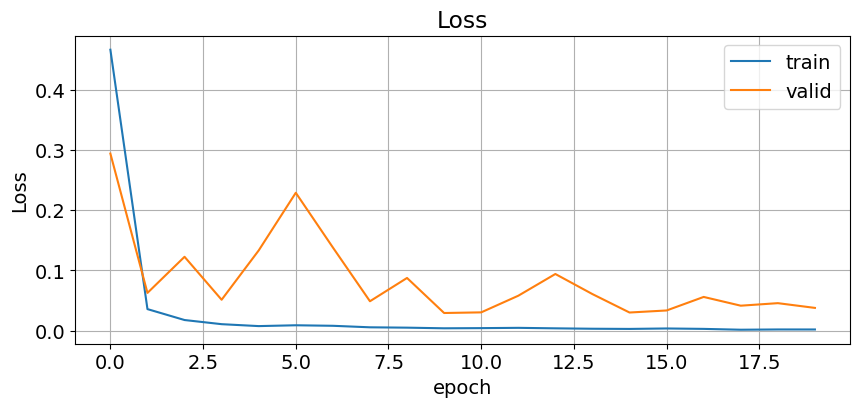

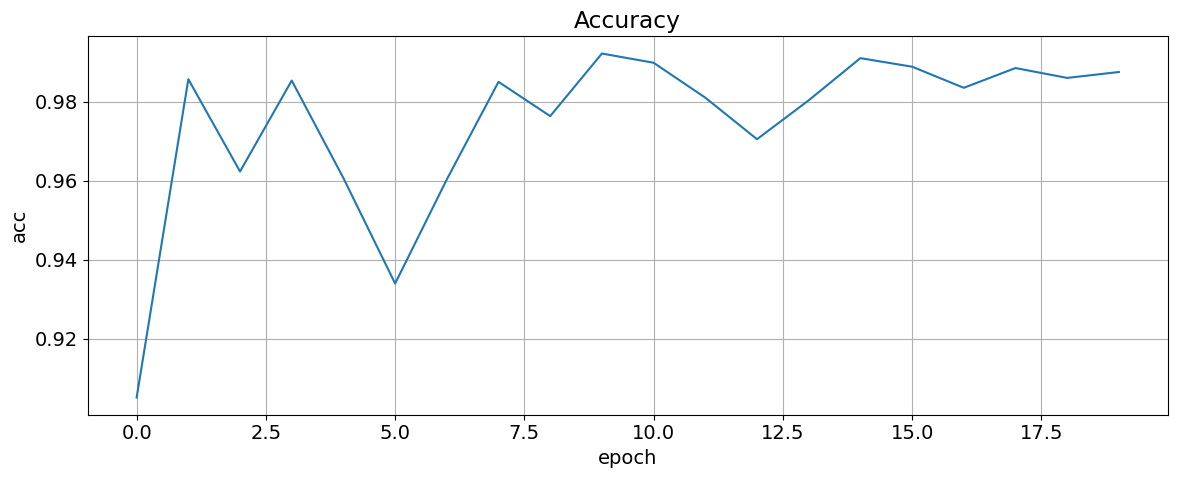

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(train_loss, label=f'train')
ax.plot(val_loss, label=f'valid')

plt.title('Loss')
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.figure(figsize=(12, 5))
plt.plot(acc)
plt.title(f'Accuracy')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.grid(True)

plt.tight_layout()
plt.show()

## Task 2(2 points)

Train the Multi-Format Contrastive Learning of Audio Representations model (implemented during the seminar) until convergence. Plot the loss and accuracy curves to verify that the training process has stabilized.

In [9]:
# Освобождение памяти
for idx in range(3):
    gc.collect()
    torch.cuda.empty_cache()

In [10]:
def device_as(t1, t2):
   return t1.to(t2.device)

class ContrastiveLoss(nn.Module):
  def __init__(self, temperature=0.5):
    super().__init__()
    self.temperature = temperature

  def calc_similarity_batch(self, a, b):
    rep = torch.cat([a,b])
    return F.cosine_similarity(rep.unsqueeze(1), rep.unsqueeze(0), dim=2)

  def forward(self, proj_1, proj_2):
    batch_size = proj_1.shape[0]
    z_i = F.normalize(proj_1, p=2, dim=1)
    z_j = F.normalize(proj_2, p=2, dim=1)

    similarity_matrix = self.calc_similarity_batch(z_i, z_j)

    #######
    #aa#ab#
    #######
    #ba#bb#
    #######

    sim_ij = torch.diag(similarity_matrix, batch_size)
    sim_ji = torch.diag(similarity_matrix, -batch_size)

    positives = torch.cat([sim_ij, sim_ji])

    nominator = torch.exp(positives / self.temperature)

    mask = (~torch.eye(batch_size*2, batch_size*2).bool()).float()
    mask = device_as(mask, similarity_matrix)

    denominator = mask * torch.exp(similarity_matrix / self.temperature)
    all_losses = -torch.log(nominator / torch.sum(denominator))
    loss = torch.sum(all_losses) / (2*batch_size)

    return loss

def create(config):
    model = Net(img_channels=config.IMG_CHANNEL).to(device)

    loss = ContrastiveLoss()

    #Define Melspectogram and STFT (Magnitude and Phase)
    mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128,f_min=40, f_max=8000, mel_scale="slaney").to(device)

    optimizer = optim.Adam(model.parameters(), lr=config.LR, betas=(config.B1, config.B2), weight_decay=config.WEIGHT_DECAY)

    return model, loss, optimizer, mel_transform

def train(model, closs, optimizer, trainloader, valloader, config, mel_transform, stft_trasform):

    scaler = torch.amp.GradScaler()

    best_acc = 0
    accuracy = []
    train_losses = []
    for epoch in range(config.EPOCHS):
        progress_bar = tqdm(total=len(trainloader), unit='step')
        losses = []

        for audio,lab in trainloader:
            optimizer.zero_grad()

            audio = audio.to(device)

            # Create augmentation and spectograms!
            spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=True)

            with torch.amp.autocast(device_type=str(device)):
                audio_emb, spect_emb, _, _ = model(spectograms, audios)
                loss = closs(audio_emb, spect_emb)

            # Calculate loss and backward
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            #progress bar stuff
            progress_bar.set_description(f"Epoch {epoch+1}/{config.EPOCHS}")
            progress_bar.set_postfix(loss=loss.item())  # Update the loss value
            progress_bar.update(1)

            # save loss to statistics
            losses.append(loss.item())
        train_losses.append(np.mean(losses))
        # end for batch

        accuracy_test = evaluationphase(model, trainloader, valloader, config, mel_transform, stft_trasform)
        accuracy.append(accuracy_test)
        if accuracy_test > best_acc:
            best_acc = accuracy_test
            print(f'save model. epoch: {epoch}, acc: {accuracy_test:.4f}, train loss: {train_losses[-1]:.4f}')
            torch.save(model.state_dict(), f"models/model_{config.MODEL_TITLE}.pt")

    return train_losses, accuracy


def evaluationphase(model, trainloader, valloader, config, mel_transform, stft_trasform):

    model.eval()
    # Get dataloaders
    # Freeze the gradients for model1
    for param in model.parameters():
        param.requires_grad = False

    def train_head(model, dataloader):
        modelEvaluation = EvaluationHead(num_classes = config.CLASSES).to(device)

        # Define the optimizer, the paper use
        optimizer = optim.Adam(modelEvaluation.parameters(), lr=config.LR)
        criterion = torch.nn.CrossEntropyLoss()

        for epoch in range(config.EVAL_EPOCHS):
            progress_bar = tqdm(total=len(dataloader), unit='step', leave=False)
            losses = []
            for audio, labels in dataloader:
                optimizer.zero_grad()
                audio = audio.to(device)
                # Create augmentation and spectograms!
                spectograms, audios = createModelInput(audio, mel_transform, stft_trasform, augmentation=False)

                labels = labels.to(device)

                # Use frozen encoder
                with torch.no_grad():
                    _, _, frozen_audio, frozen_spects = model(spectograms, audios)

                outputs = modelEvaluation(frozen_spects)
                loss = criterion(outputs, labels)

                # Calculate loss and backward
                loss.backward()
                optimizer.step()

                losses.append(loss.item())

                #progress bar stuff
                progress_bar.set_description(f"Head tuning epoch {epoch+1}/{config.EVAL_EPOCHS}")
                progress_bar.set_postfix(loss=np.mean(losses))  # Update the loss value
                progress_bar.update(1)
            # end for batch

        return modelEvaluation

    def evaluation(model, model_eval, dataloader):
        model_eval.eval()
        progress_bar = tqdm(total=len(dataloader), unit='step')
        total = 0
        correct = 0
        with torch.no_grad():
            for i, (audio,labels) in enumerate(dataloader):

                audio = audio.to(device)
                spectograms,audios = createModelInput(audio, mel_transform, stft_trasform,  augmentation=False)
                labels = labels.to(device)

                # Use frozen encoder
                _, _, frozen_audio, frozen_spects = model(spectograms, audios)
                outputs = model_eval(frozen_spects)
                _, predicated = torch.max(outputs.data, 1)
                total += labels.size(0)

                correct += (predicated == labels).sum().item()

                #progress bar stuff
                progress_bar.set_description(f"Evaluation {i+1}/{len(dataloader)}")
                progress_bar.update(1)
            # end for batch

        return correct/total


    model_ = train_head(model, trainloader)
    accuracy_test = evaluation(model, model_, valloader)
    print(f"Accuracy on validation: {accuracy_test:.4f}")

    model.train()
    for param in model.parameters():
        param.requires_grad = True

    return accuracy_test

In [11]:
hyperparameters = {
        'LR': 2e-4,
        'WEIGHT_DECAY': 1e-6,
        'B1':0.9,
        'B2':0.999,
        'EPOCHS': 30,
        'BATCH_SIZE': 384,
        'IMG_CHANNEL': 1,
        'CLASSES': 10,
        'EVAL_BATCH':384,
        'EVAL_EPOCHS':3,
        'MODEL_TITLE': 'contrastive'
}

config = DictConfig(hyperparameters)

model, loss, optimizer, mel_transform = create(config)

train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate, num_workers=5)
val_loader  = DataLoader(valid_ds,  batch_size=config.EVAL_BATCH, shuffle=False, collate_fn=collate, num_workers=5)

losses, acc = train(model, loss, optimizer, train_loader, val_loader, config, mel_transform, None)

  0%|          | 0/63 [00:00<?, ?step/s]

  0%|          | 0/63 [00:00<?, ?step/s]

  0%|          | 0/63 [00:00<?, ?step/s]

  0%|          | 0/63 [00:00<?, ?step/s]

  0%|          | 0/16 [00:00<?, ?step/s]

...

  0%|          | 0/63 [00:00<?, ?step/s]

  0%|          | 0/63 [00:00<?, ?step/s]

  0%|          | 0/63 [00:00<?, ?step/s]

  0%|          | 0/16 [00:00<?, ?step/s]

Accuracy on validation: 0.6467


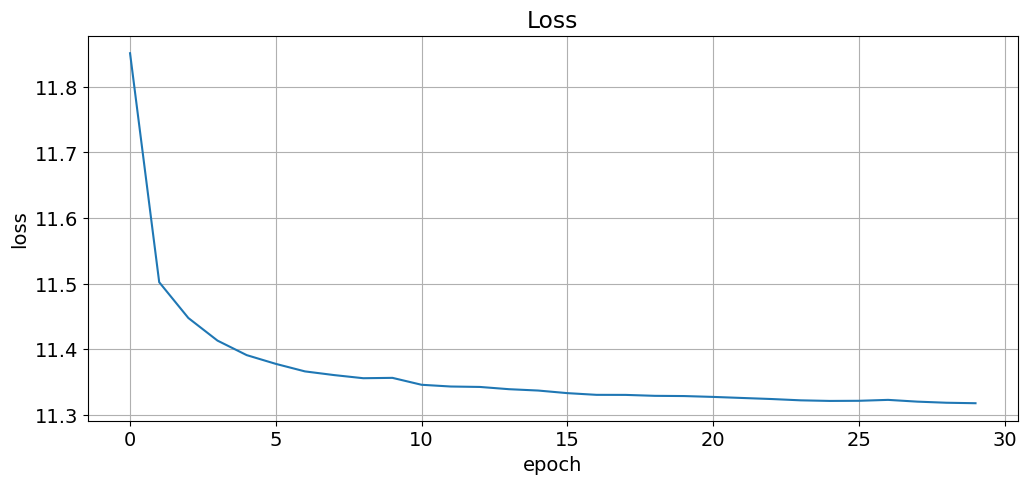

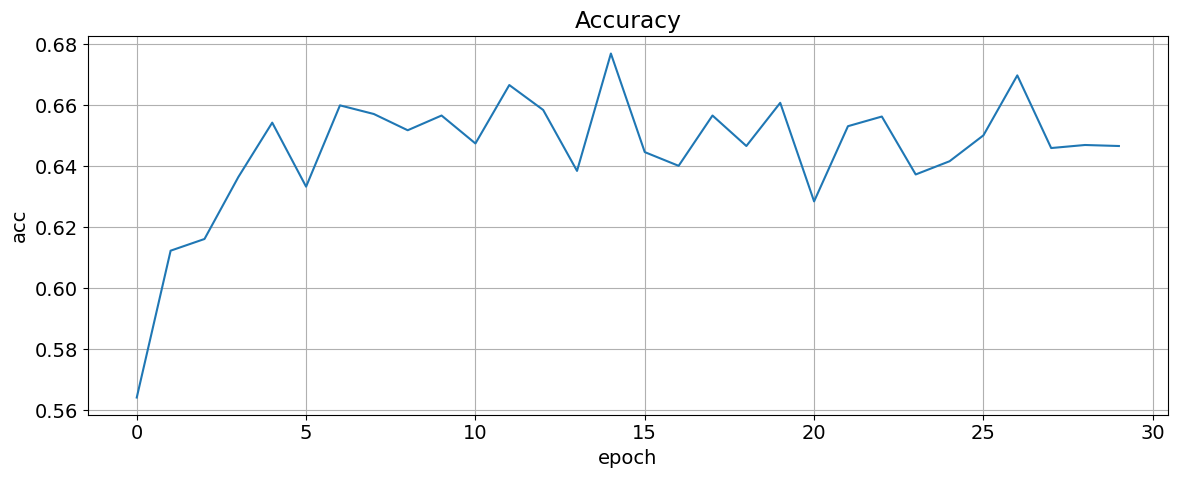

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(losses)
plt.title(f'Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True)

plt.figure(figsize=(12, 5))
plt.plot(acc)
plt.title(f'Accuracy')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.grid(True)

plt.tight_layout()
plt.show()

## Task 3(4 points)

Replace the InfoNCE loss in Multi-Format Contrastive Learning of Audio Representations with a Non-Contrastive Learning method.
Train the model until convergence, then plot the loss and accuracy curves to check that training has stabilized.

You can try one of the following NCL methods:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Feel free to use a more recent Non-Contrastive approach if you prefer—just explain briefly why you chose it.


Возьму ArcFace loss. Его цель распределить эмбеддинги на гиперсфере так, чтобы вектора одного класса были кучно, а разных классов далеко друг от друга. Отличие от Contrastive Loss в том, что в ArcFace - негативный пример это не просто случайных другой объект, а конкретный представитель другого известного класса. Это позволяет создавать четкие и равномерно разнесенные кластеры

In [13]:
# Освобождение памяти
for idx in range(3):
    gc.collect()
    torch.cuda.empty_cache()

In [14]:
class ArcFaceLoss(nn.Module):
    def __init__(self, num_classes, embedding_size, margin=0.5, scale=64.0):
        super(ArcFaceLoss, self).__init__()
        self.num_classes = num_classes
        self.embedding_size = embedding_size
        self.margin = margin
        self.scale = scale
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin

    def forward(self, embeddings, labels):
        normalized_embeddings = F.normalize(embeddings)
        normalized_weight = F.normalize(self.weight)

        cosine = F.linear(normalized_embeddings, normalized_weight)

        sine = torch.sqrt(1.0 - torch.pow(cosine, 2) + 1e-9)
        cos_theta_m = cosine * self.cos_m - sine * self.sin_m  # cos(θ + m)

        cos_theta_m = torch.where(cosine > self.th, cos_theta_m, cosine - self.mm)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)

        output = (one_hot * cos_theta_m) + ((1.0 - one_hot) * cosine)
        output *= self.scale

        return F.cross_entropy(output, labels)

def create(config):
  model = Net(img_channels=config.IMG_CHANNEL).to(device)

  loss = ArcFaceLoss(num_classes=config.CLASSES, embedding_size=128).to(device)

  mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128,f_min=40, f_max=8000, mel_scale="slaney").to(device)

  optimizer = optim.AdamW(list(model.parameters()) + list(loss.parameters()), lr=config.LR)

  return model, loss, optimizer, mel_transform

def train(model, closs, optimizer, trainloader, valloader, config, mel_transform, stft_trasform):

    scaler = torch.amp.GradScaler()

    best_acc = 0
    accuracy = []
    train_losses = []
    progress_bar = tqdm(total=config.EPOCHS, unit='epoch')
    for epoch in range(config.EPOCHS):
        losses = []

        model.train()
        closs.train()
        for audio,lab in trainloader:
            optimizer.zero_grad()

            audio = audio.to(device)
            lab = lab.to(device)

            spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=True)

            with torch.amp.autocast(device_type=str(device)):
                audio_emb, spect_emb, _, _ = model(spectograms, audios)
                loss = closs(spect_emb, lab)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            losses.append(loss.item())
        train_losses.append(np.mean(losses))

        progress_bar.set_description(f"Epoch {epoch + 1}/{config.EPOCHS}")
        progress_bar.set_postfix(loss=losses[-1])
        progress_bar.update(1)
        # end for batch

        accuracy_test = evaluationphase(model, closs, valloader, mel_transform, stft_trasform)
        print(f"Accuracy on validation: {accuracy_test:.4f}")
        
        accuracy.append(accuracy_test)
        if accuracy_test > best_acc:
            best_acc = accuracy_test
            print(f'save model. epoch: {epoch}, acc: {accuracy_test:.4f}, train loss: {train_losses[-1]:.4f}')
            torch.save(model.state_dict(), f"models/model_{config.MODEL_TITLE}.pt")

    return train_losses, accuracy


def evaluationphase(model, closs, valloader, mel_transform, stft_trasform):
    model.eval()
    closs.eval()
    
    total = 0
    correct = 0
    with torch.no_grad():
        for i, (audio,labels) in enumerate(valloader):

            audio = audio.to(device)
            spectograms,audios = createModelInput(audio, mel_transform, stft_trasform,  augmentation=False)
            labels = labels.to(device)

            _, spect_emb, _, _ = model(spectograms, audios)
            
            cosine = F.linear(F.normalize(spect_emb), F.normalize(closs.weight))
            _, predicated = torch.max(cosine.data, 1)
            
            total += labels.size(0)

            correct += (predicated == labels).sum().item()

    accuracy_test = correct/total

    return accuracy_test

In [15]:
hyperparameters = {
        'LR': 2e-4,
        'WEIGHT_DECAY': 1e-6,
        'EPOCHS': 30,
        'BATCH_SIZE': 256,
        'IMG_CHANNEL': 1,
        'CLASSES': 10,
        'EVAL_BATCH':256,
        'MODEL_TITLE': 'arcface'
}

config = DictConfig(hyperparameters)

train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate, num_workers=5)
val_loader  = DataLoader(valid_ds,  batch_size=config.EVAL_BATCH, shuffle=False, collate_fn=collate, num_workers=5)

model, loss, optimizer, mel_transform = create(config)

losses, acc = train(model, loss, optimizer, train_loader, val_loader, config, mel_transform, None)

  0%|          | 0/30 [00:00<?, ?epoch/s]

Accuracy on validation: 0.9243
save model. epoch: 0, acc: 0.9243, train loss: 9.9845
Accuracy on validation: 0.9513
save model. epoch: 1, acc: 0.9513, train loss: 0.7792
Accuracy on validation: 0.9798
save model. epoch: 2, acc: 0.9798, train loss: 0.4559
Accuracy on validation: 0.9428
Accuracy on validation: 0.9723
Accuracy on validation: 0.9653
Accuracy on validation: 0.9678
Accuracy on validation: 0.9758
Accuracy on validation: 0.9338
Accuracy on validation: 0.9688
Accuracy on validation: 0.9585
Accuracy on validation: 0.9867
save model. epoch: 11, acc: 0.9867, train loss: 0.1658
Accuracy on validation: 0.9453
Accuracy on validation: 0.9295
Accuracy on validation: 0.9772
Accuracy on validation: 0.9470
Accuracy on validation: 0.9825
Accuracy on validation: 0.9708
Accuracy on validation: 0.9795
Accuracy on validation: 0.9697
Accuracy on validation: 0.9705
Accuracy on validation: 0.9860
Accuracy on validation: 0.9692
Accuracy on validation: 0.9930
save model. epoch: 23, acc: 0.9930, tra

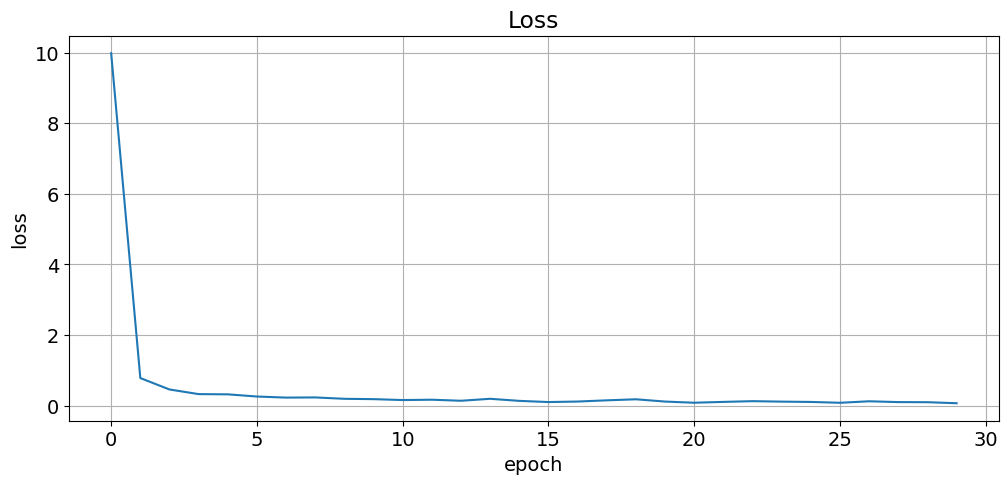

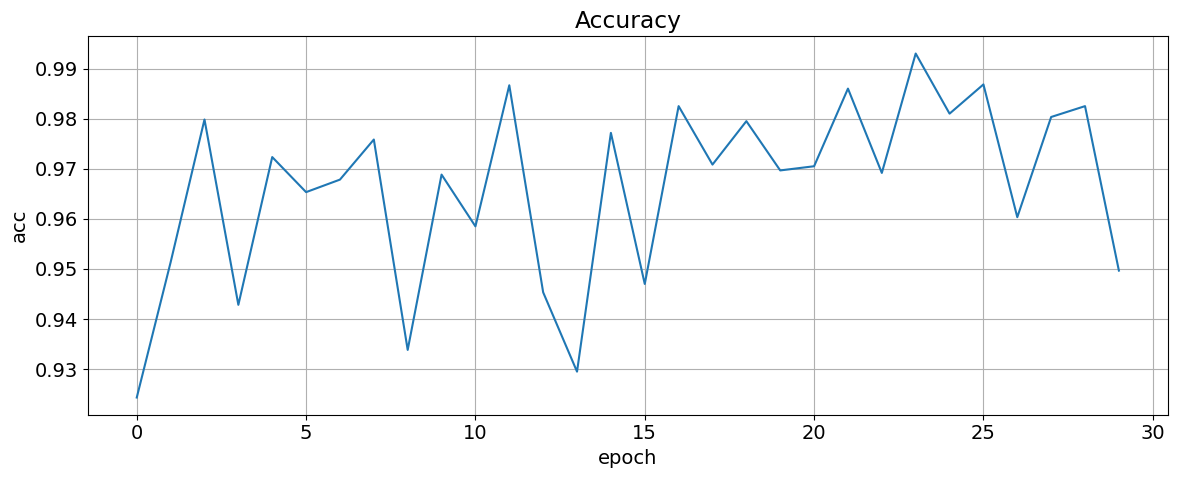

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(losses)
plt.title(f'Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True)

plt.figure(figsize=(12, 5))
plt.plot(acc)
plt.title(f'Accuracy')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.grid(True)

plt.tight_layout()
plt.show()

## Task 4(2 points)

Evaluate and compare three training setups on the validation subset:

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

Use either the 2D or 1D encoder—or combine their embeddings.
Identify which setup performs best and explain why it outperforms the others.

Расчеты проводились локально, так как основное время занимает чтение данных, поставил в даталоадере 5 воркеров, что загрузило GPU на 90% 

1. Обучение с учителем. 
    Обучение на сыром аудио достигает точности 92%. Обучение на спектрограммах достигло точности 99.21% на 12 эпохе.
    Подбор параметров не проводил. Обучение на данных аудио и спектрограмм совместно так-же не проводил
2. Обучение c contrastive loss.
   Скопировал код с семинара, увеличил количество эпох до 30, учил только на спектрограммах. На 16-й эпохе получил точность 67.7%
4. Взял ArcFace Loss. Он разносит вектора разных классов на гиперсфере. Часто используется для классификации лиц. Получил точность 99.3% на 23-й эпохе

На этой задаче и этом датасете прекрасно себя показала прямая классификация, то-есть 1-й вариант. В прошлые запуски получилось достичь 99.5%. 
Из двух оставшихся вариантов ArcFace оказался значительно лучше. Его эмбеддинги более качественные. Думаю, это связано с тем, что у него более гармонично распределяются классы, можно сказать что они в первом приближении равноудалены друг от друга

In [19]:
# Визуализация эмбеддингов ArcFace - спектрограммные хорошо разделимы

In [17]:
def extract_embeddings(model, dataloader):
    model.eval()
    progress_bar = tqdm(total=len(dataloader), unit='step')
    embeddings_audio = []
    embeddings_spec = []
    labels_ = []
    with torch.no_grad():
        for i, (audio,labels) in enumerate(dataloader):

            audio = audio.to(device)
            spectograms, audios = createModelInput(audio, mel_transform, None,  augmentation=False)

            # Use frozen encoder
            _, _, frozen_audio, frozen_spects = model(spectograms, audios)
            #embed = torch.cat([frozen_audio, frozen_spects], dim = 0).cpu()
            embeddings_audio.append(frozen_audio.cpu())
            embeddings_spec.append(frozen_spects.cpu())
            labels_.append(labels.cpu())

            progress_bar.update(1)

        # end for batch
    return torch.cat(embeddings_audio, dim=0).numpy(), torch.cat(embeddings_spec, dim=0).numpy(), torch.cat(labels_, dim=0).numpy()


def tsne_plot(X: np.ndarray, y: np.ndarray, out_path: str = "tsne.png", name = ""):
    # Compute 2D t-SNE and save
    tsne = TSNE(n_components=2, init="random", learning_rate="auto", perplexity=min(30, max(5, len(X)//50)), n_iter=1000)
    X2 = tsne.fit_transform(X)
    plt.figure(figsize=(7, 6))
    for cls in sorted(set(y.tolist())):
        idx = (y == cls)
        plt.scatter(X2[idx, 0], X2[idx, 1], label=str(cls), s=10, alpha=0.7)
    plt.legend(title="Digit", loc="best")
    plt.title(f"t-SNE of {name} embeddings (AudioMNIST)")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    print(f"Saved t-SNE figure to {out_path}")

  0%|          | 0/94 [00:00<?, ?step/s]

Saved t-SNE figure to tsne.png
Saved t-SNE figure to tsne.png


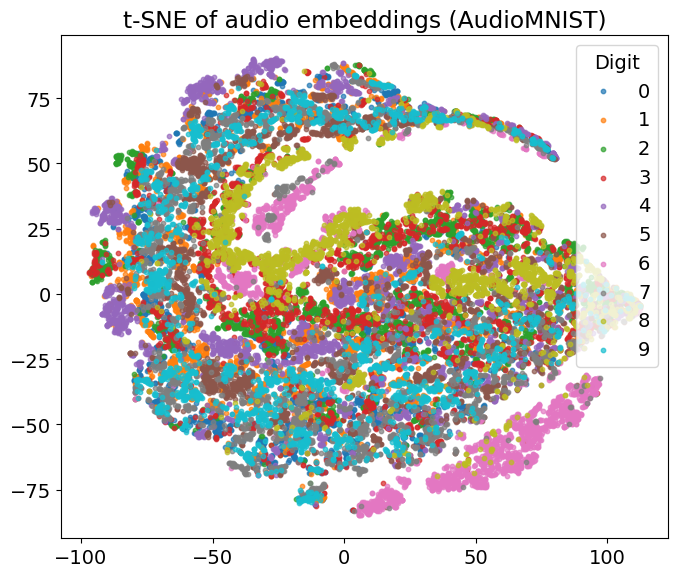

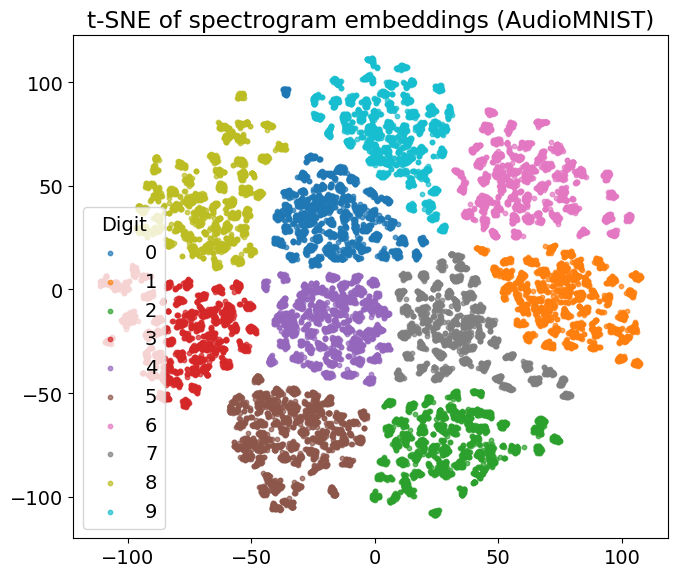

In [18]:
_embeddings_audio, _embeddings_spec, _labels = extract_embeddings(model, train_loader)
tsne_plot(_embeddings_audio, _labels, name="audio")
tsne_plot(_embeddings_spec, _labels, name="spectrogram")